### LUT via AlliedVision camera:

The SLM does not naturally give a linear relation between digital gray value and optical phase. The LUT corrects that nonlinearity.

#### Find what Meadowlark is already installed

In [1]:
import matplotlib.pyplot as plt
from matplotlib_inline.backend_inline import set_matplotlib_formats

# Sharper inline plots in Jupyter
set_matplotlib_formats("retina")

# Kunal's physics plotting style
plt.style.use(
    "https://raw.githubusercontent.com/"
    "ksingh1121/python-plot-style/main/physics.mplstyle"
)

In [2]:
from pathlib import Path

BLINK_ROOT = Path(
    r"C:\Program Files\Meadowlark Optics\Blink 1920 HDMI"
)

print("Searching:", BLINK_ROOT)
print()

# Look for all LUT-like files.
lut_files = sorted(
    {
        p
        for pattern in ("*.lut", "*.LUT", "*.blt", "*.BLT")
        for p in BLINK_ROOT.rglob(pattern)
    }
)

print("=== LUT / BLT files ===")

if lut_files:
    for p in lut_files:
        print(p)
else:
    print("No LUT/BLT files found.")

print()


# Look specifically for Meadowlark calibration-related files/examples.
keywords = (
    "linear",
    "diffractive",
    "hdmidiffractivetest",
    "diffractivelut",
)

calibration_files = sorted(
    p
    for p in BLINK_ROOT.rglob("*")
    if p.is_file()
    and any(word in p.name.lower() for word in keywords)
)

print("=== Calibration-related files ===")

if calibration_files:
    for p in calibration_files:
        print(p)
else:
    print("No obvious calibration-related files found.")

Searching: C:\Program Files\Meadowlark Optics\Blink 1920 HDMI

=== LUT / BLT files ===
C:\Program Files\Meadowlark Optics\Blink 1920 HDMI\LUT Files\1920x1152_linearVoltage.lut
C:\Program Files\Meadowlark Optics\Blink 1920 HDMI\LUT Files\19x12_10bit_linearVoltage.lut
C:\Program Files\Meadowlark Optics\Blink 1920 HDMI\LUT Files\19x12_8bit_linearVoltage.lut

=== Calibration-related files ===
C:\Program Files\Meadowlark Optics\Blink 1920 HDMI\Cal Kit\DiffractiveLUT.exe
C:\Program Files\Meadowlark Optics\Blink 1920 HDMI\Cal Kit\HDMIDiffractiveTest.cpp
C:\Program Files\Meadowlark Optics\Blink 1920 HDMI\Cal Kit\HDMIDiffractiveTest.m
C:\Program Files\Meadowlark Optics\Blink 1920 HDMI\Cal Kit\HDMIDiffractiveTest.vcxproj
C:\Program Files\Meadowlark Optics\Blink 1920 HDMI\Cal Kit\HDMIDiffractiveTest.vi
C:\Program Files\Meadowlark Optics\Blink 1920 HDMI\LUT Files\1920x1152_linearVoltage.lut
C:\Program Files\Meadowlark Optics\Blink 1920 HDMI\LUT Files\19x12_10bit_linearVoltage.lut
C:\Program Files\

In [3]:
from pathlib import Path

CAL_CPP = Path(
    r"C:\Program Files\Meadowlark Optics\Blink 1920 HDMI"
    r"\Cal Kit\HDMIDiffractiveTest.cpp"
)

print("File:", CAL_CPP)
print("Exists:", CAL_CPP.exists())
print()

text = CAL_CPP.read_text(errors="ignore")
lines = text.splitlines()

keywords = [
    "lut",
    "linear",
    "depth",
    "bit",
    "1920",
    "1200",
    "reference",
    "gray",
    "grayscale",
]

print("=== Relevant lines from HDMIDiffractiveTest.cpp ===\n")

for i, line in enumerate(lines, start=1):
    if any(key in line.lower() for key in keywords):
        print(f"{i:4d}: {line}")

File: C:\Program Files\Meadowlark Optics\Blink 1920 HDMI\Cal Kit\HDMIDiffractiveTest.cpp
Exists: True

=== Relevant lines from HDMIDiffractiveTest.cpp ===

  12: // a regional or global LUT.
  19: 	//The number of data points we will use in the calibration is 256 (8 bit's)
  29: 	//Read the height and width of the SLM found. The default is 1920x1152 if no SLM is found. The default location
  30: 	//is immediately right of the primary monitor. If you monitor is smaller than 1920x1152 you can still run, you will
  34: 	int depth = Get_Depth(); //will return 8 for 8-bit, or 10 for 10-bit
  37: 	// To measure the raw response we want to disable the LUT by loading a linear LUT. If you are testing the linearity of 
  38: 	// your calibration, load the custom LUT that you generated (or we generated).
  40: 		Load_lut("C:\\Program Files\\Meadowlark Optics\\Blink 1920 HDMI\\LUT Files\\1920x1152_linearVoltage.lut");
  43: 	  if(depth == 8)
  44: 		  Load_lut("C:\\Program Files\\Meadowlark Optics

The calibration logic will be:

np.uint8 image containing literal gray values 0...255\
        ↓\
slmsuite passes gray values directly\
        ↓\
LINEAR Meadowlark LUT\
        ↓\
raw SLM drive voltage\
        ↓\
actual LC phase response

In [4]:
import gc

from slmsuite.hardware.cameras.alliedvision import AlliedVision

# Remove the currently broken camera object BEFORE restarting VmbPy.
try:
    del cam
except NameError:
    pass

# Force destruction/cleanup of any old camera objects now,
# before we initialize a fresh SDK.
gc.collect()

# The underlying VmbPy API is already stopped, but slmsuite may still
# hold a stale reference to its singleton object.
AlliedVision.sdk = None

# Now initialize exactly one fresh camera instance.
cam = AlliedVision(
    serial="015C2",
    pitch_um=2.4,
    verbose=True,
)

print("\n=== Fresh camera ready ===")
print("Name  :", cam.name)
print("Shape :", cam.shape)

vmbpy initializing... success
Looking for cameras... success


RuntimeError: Serial 015C2 not found by vmbpy. Available: ['0D512', '02775', '0D4A9']

In [ ]:
# Apply the known-good hardware ROI
cam.set_woi((1948, 1600, 1036, 1600))

# Acquire one frame
image = cam.get_image()

print("cam.shape metadata :", cam.shape)
print("Actual image shape :", image.shape)
print("Image min          :", image.min())
print("Image max          :", image.max())

cam.shape metadata : (3672, 5496)
Actual image shape : (1600, 1600)
Image min          : 0
Image max          : 207


Exposure [ms]     : 0.497181
Gain              : 0.0
Actual image shape: (1600, 1600)
Image min         : 0
Image max         : 184
Pixels at 255     : 0


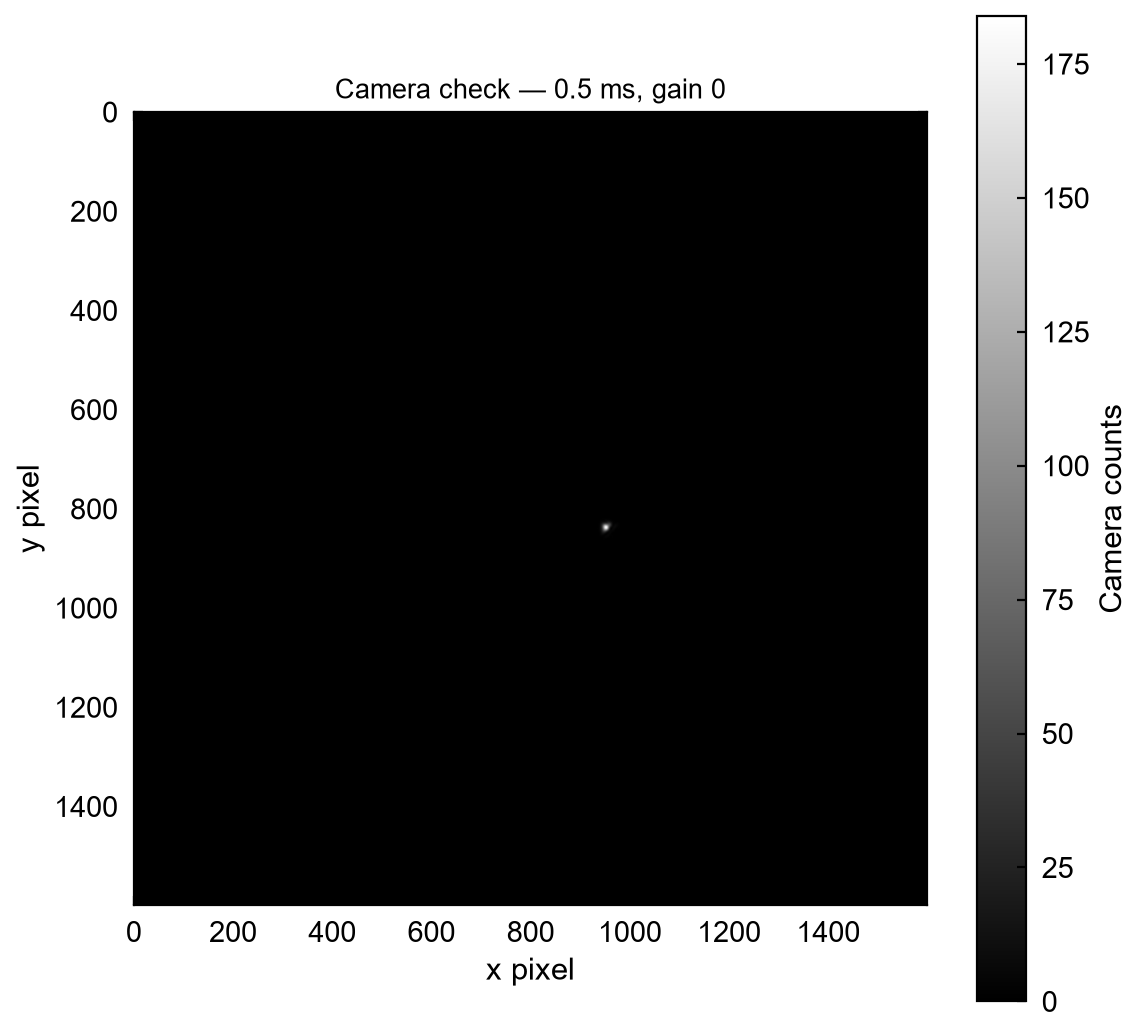

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Restore known working camera settings
cam.cam.GainAuto.set("Off")
cam.cam.ExposureAuto.set("Off")
cam.cam.Gain.set(0)

cam.set_exposure(0.5e-3)   # seconds = 0.5 ms

# Acquire one fresh frame
image = cam.get_image()

print("Exposure [ms]     :", 1e3 * cam.get_exposure())
print("Gain              :", cam.cam.Gain.get())
print("Actual image shape:", image.shape)
print("Image min         :", image.min())
print("Image max         :", image.max())
print("Pixels at 255     :", np.sum(image == 255))

plt.figure(figsize=(8, 8))
plt.imshow(image, cmap="gray", origin="upper")
plt.colorbar(label="Camera counts")
plt.xlabel("x pixel")
plt.ylabel("y pixel")
plt.title("Camera check — 0.5 ms, gain 0")
plt.show()

In [ ]:
from pathlib import Path
from slmsuite.hardware.slms.meadowlark import Meadowlark

SDK_PATH = Path(
    r"C:\Program Files\Meadowlark Optics\Blink 1920 HDMI\SDK"
)

FAN_LUT_PATH = Path(
    r"C:\Users\admin\Desktop\Projects\SLM"
    r"\LUT from Fan\759nm_roomtemp_global"
    r"\759nm_roomtemp_global"
    r"\759nm_rommtemp_global.lut"
)

print("SDK exists     :", SDK_PATH.exists())
print("Fan LUT exists :", FAN_LUT_PATH.exists())

slm = Meadowlark(
    slm_number=1,
    sdk_path=str(SDK_PATH),
    lut_path=str(FAN_LUT_PATH),
    wav_um=0.759,
    verbose=True,
)

print("\n=== SLM ready ===")
print("Name      :", slm.name)
print("Shape     :", slm.shape)
print("Bit depth :", slm.bitdepth)
print("Pixel pitch [um]:", slm.pitch)

SDK exists     : True
Fan LUT exists : True
Validating DPI awareness...success
Constructing Blink SDK...success
Loading LUT file...
=== SLM ready ===
Name      : Meadowlark HDMI
Shape     : (1200, 1920)
Bit depth : 8
Pixel pitch [um]: [10.54018445 10.54018445]


In [ ]:
print("Physical pixel pitch [um] :", slm.pitch_um)
print("Wavelength [um]           :", slm.wav_um)
print("Normalized pitch [lambda] :", slm.pitch)
print("Check pitch_um / wav_um   :", slm.pitch_um / slm.wav_um)

Physical pixel pitch [um] : [8. 8.]
Wavelength [um]           : 0.759
Normalized pitch [lambda] : [10.54018445 10.54018445]
Check pitch_um / wav_um   : [10.54018445 10.54018445]


Linear LUT exists: True

=== Linear LUT loaded ===
Loaded LUT          : C:\Program Files\Meadowlark Optics\Blink 1920 HDMI\LUT Files\19x12_8bit_linearVoltage.lut
Unique SLM values   : [255]
Image shape         : (1600, 1600)
Image min           : 0
Image max           : 220
Pixels at 255       : 0


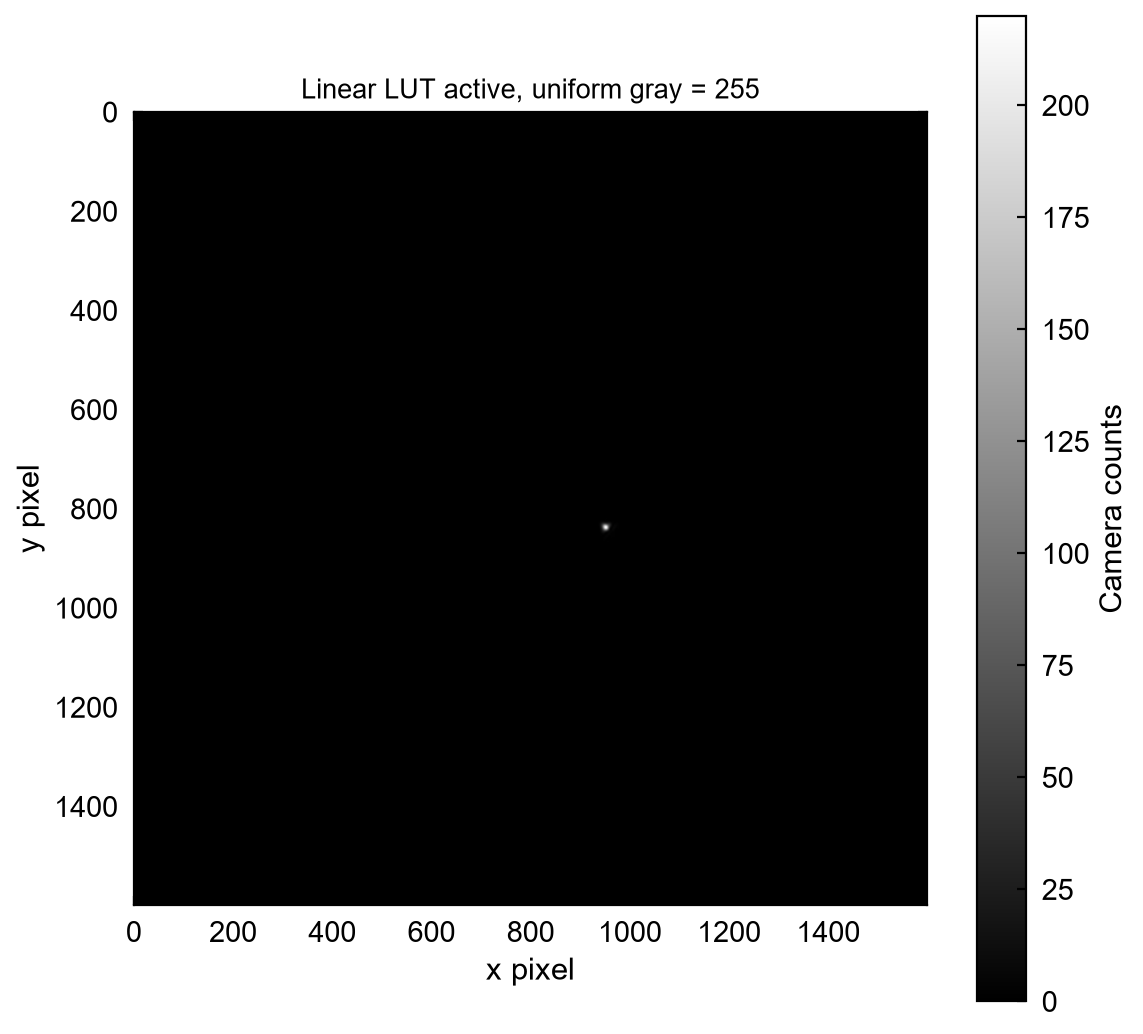

In [ ]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

LINEAR_LUT_PATH = Path(
    r"C:\Program Files\Meadowlark Optics\Blink 1920 HDMI"
    r"\LUT Files\19x12_8bit_linearVoltage.lut"
)

print("Linear LUT exists:", LINEAR_LUT_PATH.exists())
assert LINEAR_LUT_PATH.exists()

# Uniform direct gray image: literal hardware gray value 255 everywhere.
gray255 = np.full(slm.shape, 255, dtype=np.uint8)

# Put SLM in a uniform state first.
slm.set_phase(gray255, settle=True)

# Load the Meadowlark raw/linear LUT.
loaded_lut = slm.load_lut(str(LINEAR_LUT_PATH))

# Re-send the same uniform gray image after switching LUT.
slm.set_phase(gray255, settle=True)

# Acquire one camera frame.
image_linear_255 = cam.get_image()

print("\n=== Linear LUT loaded ===")
print("Loaded LUT          :", loaded_lut)
print("Unique SLM values   :", np.unique(slm.display))
print("Image shape         :", image_linear_255.shape)
print("Image min           :", image_linear_255.min())
print("Image max           :", image_linear_255.max())
print("Pixels at 255       :", np.sum(image_linear_255 == 255))

plt.figure(figsize=(8, 8))
plt.imshow(image_linear_255, cmap="gray", origin="upper")
plt.colorbar(label="Camera counts")
plt.xlabel("x pixel")
plt.ylabel("y pixel")
plt.title("Linear LUT active, uniform gray = 255")
plt.show()

Pattern dtype      : uint8
Unique gray values : [128 255]
Camera image max : 173
Pixels at 255    : 0


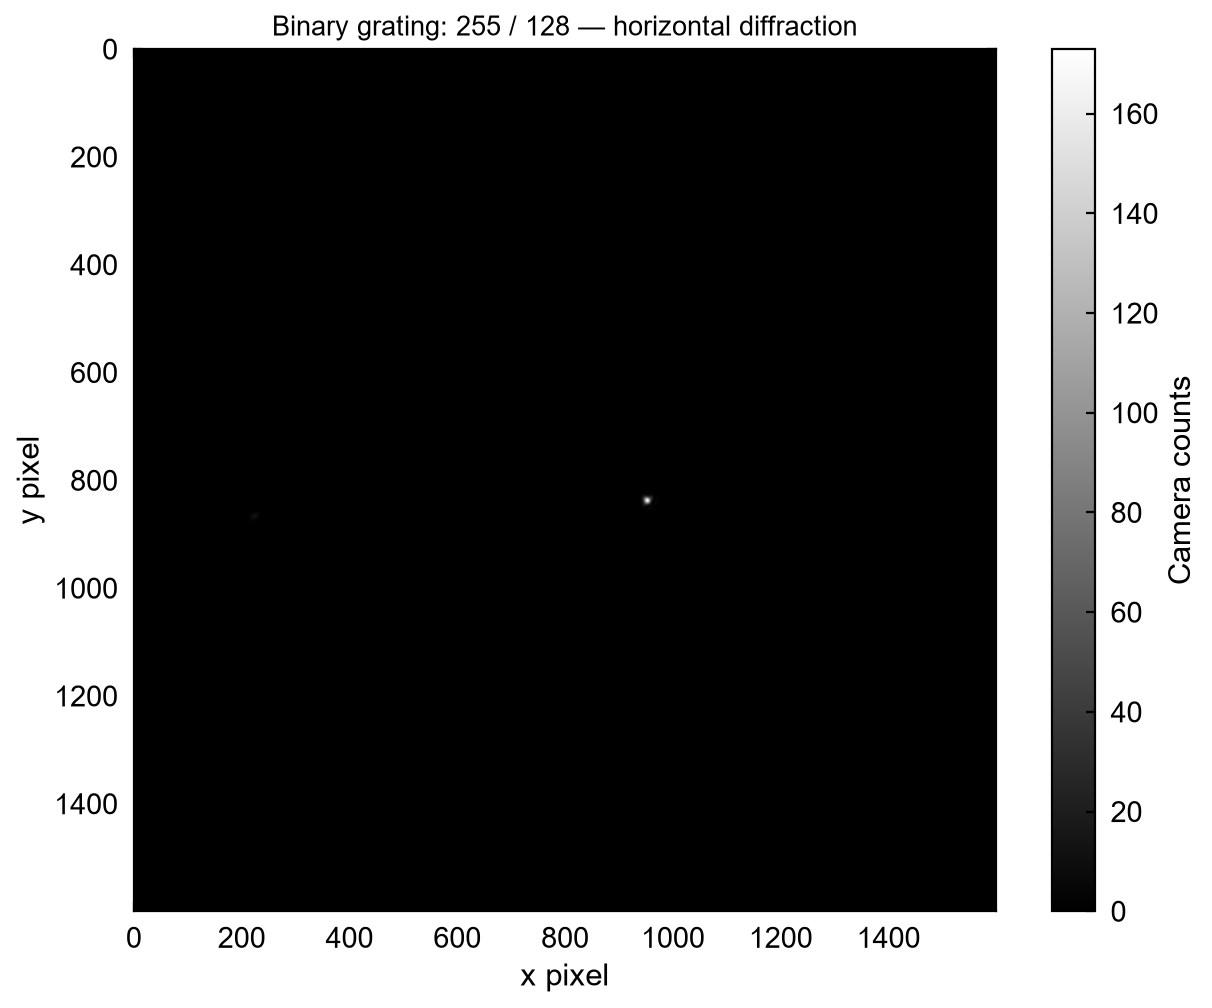

In [ ]:
REFERENCE_GRAY = 255
TEST_GRAY = 128
PIXELS_PER_STRIPE = 8

ny, nx = slm.shape

# Reference gray everywhere
binary_grating = np.full(
    (ny, nx),
    REFERENCE_GRAY,
    dtype=np.uint8
)

# Vertical stripes:
# 8 columns of 255, then 8 columns of 128, repeating.
for x0 in range(0, nx, 2 * PIXELS_PER_STRIPE):
    x1 = x0 + PIXELS_PER_STRIPE
    x2 = x0 + 2 * PIXELS_PER_STRIPE

    binary_grating[:, x1:x2] = TEST_GRAY

print("Pattern dtype      :", binary_grating.dtype)
print("Unique gray values :", np.unique(binary_grating))

slm.set_phase(binary_grating, settle=True)

image_255_128 = cam.get_image()

print("Camera image max :", image_255_128.max())
print("Pixels at 255    :", np.sum(image_255_128 == 255))

plt.figure(figsize=(9, 7))
plt.imshow(image_255_128, cmap="gray", origin="upper")
plt.colorbar(label="Camera counts")
plt.xlabel("x pixel")
plt.ylabel("y pixel")
plt.title("Binary grating: 255 / 128 — horizontal diffraction")
plt.show()